In [1]:
#Load Dataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import struct
import pandas as pd

# === Step 1: Load MNIST Dataset ===
def load_mnist_images(filename):
    with open(filename, 'rb') as f:
        _, num, rows, cols = struct.unpack(">IIII", f.read(16))
        images = np.frombuffer(f.read(), dtype=np.uint8).reshape(num, rows * cols)
        return images / 255.0

def load_mnist_labels(filename):
    with open(filename, 'rb') as f:
        _, num = struct.unpack(">II", f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
        return labels
 # Students can experiment to modify number of Train
X_train = load_mnist_images("train-images.idx3-ubyte__")[:500]
y_train = load_mnist_labels("train-labels.idx1-ubyte__")[:500]
X_test = load_mnist_images("t10k-images.idx3-ubyte__")[:200]
y_test = load_mnist_labels("t10k-labels.idx1-ubyte__")[:200]

In [2]:
# === Step 2: Activation Functions (Refer to Eq. 6.14 - 6.18) ===
def relu(x): return np.maximum(0, x)
def tanh(x): return np.tanh(x)
def softplus(x): return np.log(1 + np.exp(x))
def leaky_relu(x, alpha=0.1): return np.where(x > 0, x, alpha * x)

def one_hot(y, num_classes=10): # Refer to Equation 6.36
    return np.eye(num_classes)[y]
def cross_entropy(y_pred, y_true): # Refer to Equation 6.36
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1. - epsilon)
    return -np.sum(y_true * np.log(y_pred)) / y_pred.shape[0]
def softmax(a): # Refer to Equation 6.37
    exp_a = np.exp(a - np.max(a, axis=1, keepdims=True))
    return exp_a / np.sum(exp_a, axis=1, keepdims=True)

def forward_pass(X, weights, activations): # Forward Pass (Eq. 6.19) ===
    A = X
    for W, act in zip(weights, activations):
        Z = A @ W
        A = act(Z)
    return A

In [3]:
# === Step 3: Training Loop === # Students can experiment to modify
np.random.seed(42)
input_size = 784
hidden1 = 64
hidden2 = 16
output_size = 10
epochs = 10
best_loss = float('inf')
best_weights = None

y_train_oh = one_hot(y_train, num_classes=output_size)
y_test_oh = one_hot(y_test, num_classes=output_size)

for epoch in range(epochs):
    # TODO: Randomly initialize weights for each layer
    W1 = np.random.randn(input_size, hidden1) * 0.01
    W2 = np.random.randn(hidden1, hidden2) * 0.01
    W3 = np.random.randn(hidden2, output_size) * 0.01

    weights = [W1, W2, W3]
    activations = [relu, relu, softmax]  # Students can experiment to modify

    y_pred_train = forward_pass(X_train, weights, activations)
    loss = cross_entropy(y_pred_train, y_train_oh)

    if loss < best_loss:
        best_loss = loss
        best_weights = weights

y_pred_test = forward_pass(X_test, best_weights, activations)
y_pred_labels = np.argmax(y_pred_test, axis=1)

In [4]:
# === Step 4: Evaluation Metrics (Confusion Matrix, ROC, etc) ===
def compute_confusion_matrix(y_true, y_pred, num_classes=10): 
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

# === ROC Curve ===
def compute_roc(y_true_oh, y_pred_proba):  
    fpr, tpr = {}, {}
    for i in range(y_true_oh.shape[1]):
        probs = y_pred_proba[:, i]
        true_labels = y_true_oh[:, i]

        sort_idx = np.argsort(probs)[::-1]
        probs = probs[sort_idx]
        true_labels = true_labels[sort_idx]

        tps = np.cumsum(true_labels)
        fps = np.cumsum(1 - true_labels)

        fpr[i] = fps / fps[-1] if fps[-1] > 0 else np.zeros_like(fps)
        tpr[i] = tps / tps[-1] if tps[-1] > 0 else np.zeros_like(tps)
    return fpr, tpr

# === Classification Report === Print TP, FP, FN, TN, precision, recall, f1, accuracy
def compute_metrics(cm): 
    TP = np.diag(cm)
    FP = np.sum(cm, axis=0) - TP
    FN = np.sum(cm, axis=1) - TP
    TN = np.sum(cm) - (TP + FP + FN)

    precision = np.divide(TP, TP + FP, out=np.zeros_like(TP, dtype=float), where=(TP + FP) != 0)
    recall = np.divide(TP, TP + FN, out=np.zeros_like(TP, dtype=float), where=(TP + FN) != 0)
    f1 = np.divide(2 * precision * recall, precision + recall, out=np.zeros_like(precision, dtype=float), where=(precision + recall) != 0)
    accuracy = np.sum(TP) / np.sum(cm)
    return TP, FP, FN, TN, precision, recall, f1, accuracy

=== Classification Report ===


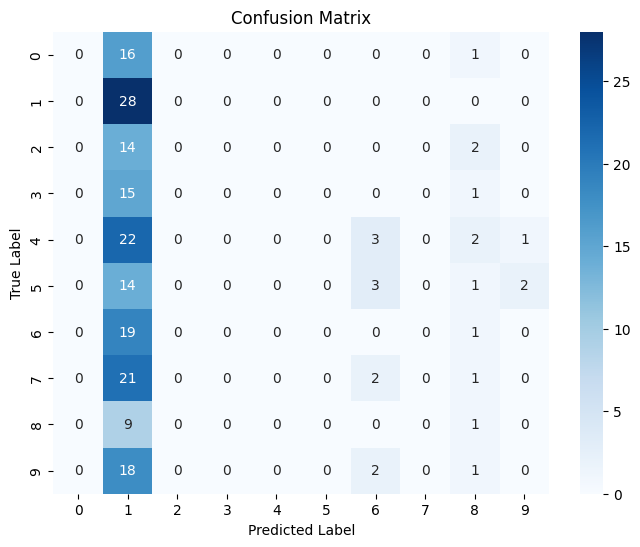

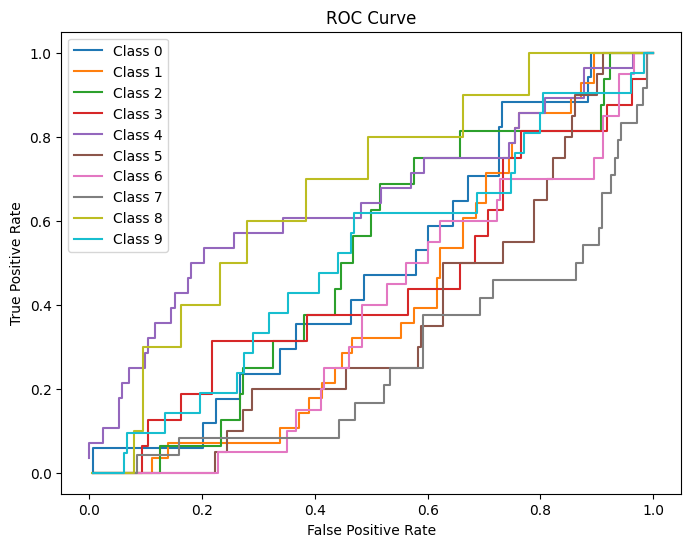

Overall Accuracy: 0.1450

Class  | TP   | FP   | FN   | TN   | Precision | Recall | F1-Score
---------------------------------------------------------------------------
0      | 0    | 0    | 17   | 183  | 0.0000    | 0.0000 | 0.0000
1      | 28   | 148  | 0    | 24   | 0.1591    | 1.0000 | 0.2745
2      | 0    | 0    | 16   | 184  | 0.0000    | 0.0000 | 0.0000
3      | 0    | 0    | 16   | 184  | 0.0000    | 0.0000 | 0.0000
4      | 0    | 0    | 28   | 172  | 0.0000    | 0.0000 | 0.0000
5      | 0    | 0    | 20   | 180  | 0.0000    | 0.0000 | 0.0000
6      | 0    | 10   | 20   | 170  | 0.0000    | 0.0000 | 0.0000
7      | 0    | 0    | 24   | 176  | 0.0000    | 0.0000 | 0.0000
8      | 1    | 10   | 9    | 180  | 0.0909    | 0.1000 | 0.0952
9      | 0    | 3    | 21   | 176  | 0.0000    | 0.0000 | 0.0000


In [5]:
cm = compute_confusion_matrix(y_test, y_pred_labels)
fpr, tpr = compute_roc(y_test_oh, y_pred_test)
TP, FP, FN, TN, precision, recall, f1, accuracy = compute_metrics(cm)

print("=== Classification Report ===")

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# ROC Curve
plt.figure(figsize=(8, 6))
for i in range(10):
    plt.plot(fpr[i], tpr[i], label=f'Class {i}')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# Precision, Recall, F1, Overall Accuracy
print(f"Overall Accuracy: {accuracy:.4f}\n")
print(f"{'Class':<6} | {'TP':<4} | {'FP':<4} | {'FN':<4} | {'TN':<4} | {'Precision':<9} | {'Recall':<6} | {'F1-Score'}")
print("-" * 75)
for i in range(10):
    print(f"{i:<6} | {TP[i]:<4} | {FP[i]:<4} | {FN[i]:<4} | {TN[i]:<4} | {precision[i]:<9.4f} | {recall[i]:<6.4f} | {f1[i]:.4f}")